In [3]:
import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Load your preprocessed dataset
data_path = r"/content/your_preprocessed_data.xlsx"  # Update with your actual file path
data = pd.read_excel(data_path)

# Define the column names for text and target labels
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Convert text data to numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data[text_column])  # Feature matrix
y = data[target_column]  # Target labels

# Step 2: Split the dataset into training (80%) and testing (20%) sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
}

# Step 4: Train and evaluate each model
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)  # Train the model

    # Save the trained model
    with open(f'{name.replace(" ", "_")}_model.pkl', 'wb') as f:
        pickle.dump(model, f)

    # Predict on the test set
    y_pred = model.predict(X_test_tfidf)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{name} Accuracy: {accuracy * 100:.2f}%")
    print(f"{name} Precision: {precision * 100:.2f}%")
    print(f"{name} Recall: {recall * 100:.2f}%")
    print(f"{name} F1 Score: {f1 * 100:.2f}%")
    print(classification_report(y_test, y_pred))

    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

# Step 5: Display results
print("\nSummary of Model Metrics:")
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  Accuracy: {metrics['Accuracy'] * 100:.2f}%")
    print(f"  Precision: {metrics['Precision'] * 100:.2f}%")
    print(f"  Recall: {metrics['Recall'] * 100:.2f}%")
    print(f"  F1 Score: {metrics['F1 Score'] * 100:.2f}%")


Training Logistic Regression...
Logistic Regression Accuracy: 93.26%
Logistic Regression Precision: 93.27%
Logistic Regression Recall: 93.26%
Logistic Regression F1 Score: 93.25%
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     23238
           1       0.94      0.92      0.93     23171

    accuracy                           0.93     46409
   macro avg       0.93      0.93      0.93     46409
weighted avg       0.93      0.93      0.93     46409

Training Naive Bayes...
Naive Bayes Accuracy: 90.39%
Naive Bayes Precision: 90.71%
Naive Bayes Recall: 90.39%
Naive Bayes F1 Score: 90.38%
              precision    recall  f1-score   support

           0       0.94      0.86      0.90     23238
           1       0.87      0.95      0.91     23171

    accuracy                           0.90     46409
   macro avg       0.91      0.90      0.90     46409
weighted avg       0.91      0.90      0.90     46409


Summary of Model Metrics:
L

Training Logistic Regression...


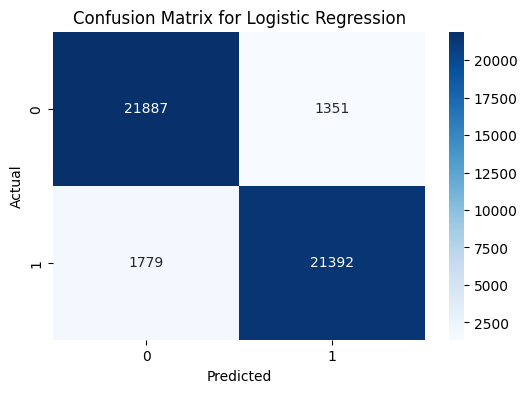

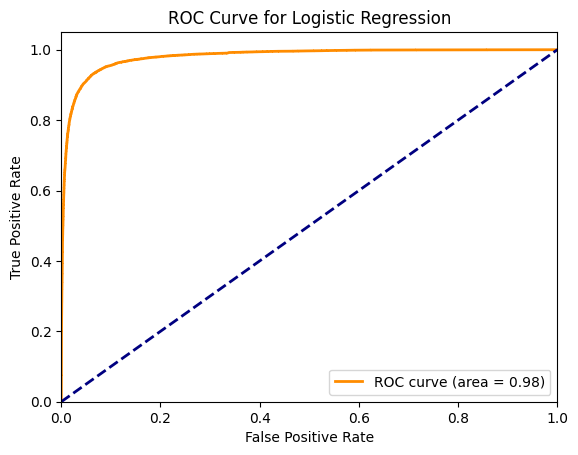

Training Naive Bayes...


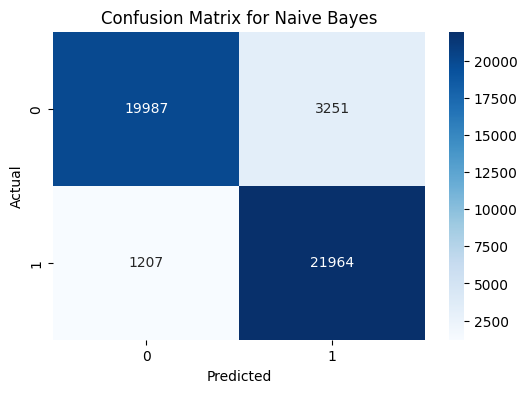

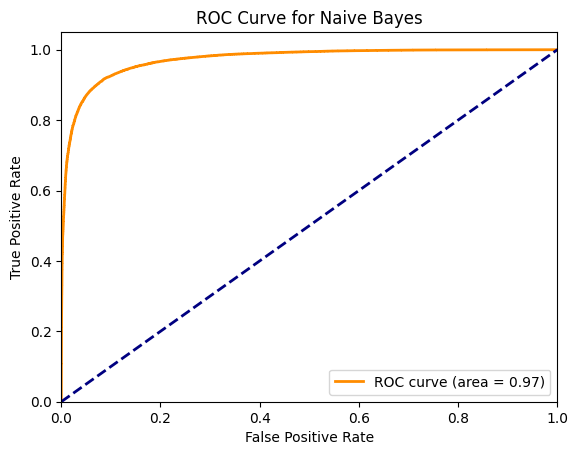

In [4]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Load your preprocessed dataset
data_path = r"/content/your_preprocessed_data.xlsx"  # Updated file path
data = pd.read_excel(data_path)

# Define the column names for text and target labels
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Convert text data to numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data[text_column])  # Feature matrix
y = data[target_column]  # Target labels

# Step 2: Split the dataset into training (80%) and testing (20%) sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
}

# Step 4: Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)  # Train the model

    # Save the trained model
    with open(f'{name.replace(" ", "_")}_model.pkl', 'wb') as f:
        pickle.dump(model, f)

    # Predict on the test set
    y_pred = model.predict(X_test_tfidf)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve (only for binary classification)
    if len(y.unique()) == 2:
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test_tfidf)[:, 1]
        else:
            y_prob = model.decision_function(X_test_tfidf)

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for {name}')
        plt.legend(loc="lower right")
        plt.show()


Evaluating error metrics for Logistic Regression...
Logistic Regression MAE: 0.0674, MSE: 0.0674, RMSE: 0.2597
Evaluating error metrics for Naive Bayes...
Naive Bayes MAE: 0.0961, MSE: 0.0961, RMSE: 0.3099


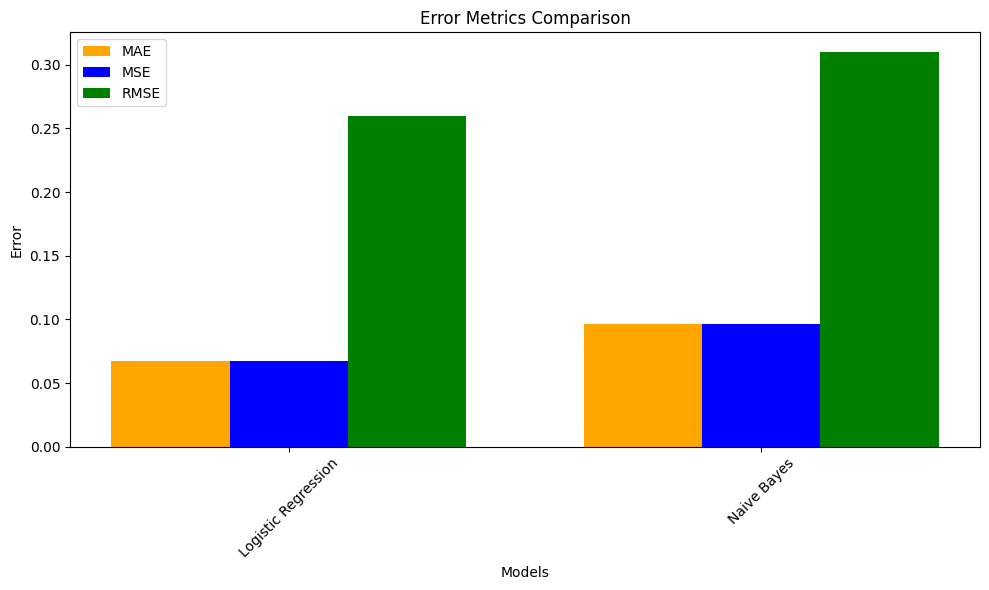

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store error metrics
error_metrics = {}

# Loop through models
for name, model in models.items():
    print(f"Evaluating error metrics for {name}...")

    # Predict on the test set
    y_pred = model.predict(X_test_tfidf)

    # Calculate error metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Store error metrics
    error_metrics[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse}

    # Print metrics
    print(f"{name} MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))  # The x positions of the bars
width = 0.25  # The width of the bars

plt.figure(figsize=(10, 6))

# Bar plots for MAE, MSE, RMSE
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

# Labels and title
plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison')
plt.xticks(x, model_names, rotation=45)  # Adjust labels to show model names
plt.legend()  # Display the legend
plt.tight_layout()

# Show the plot
plt.show()


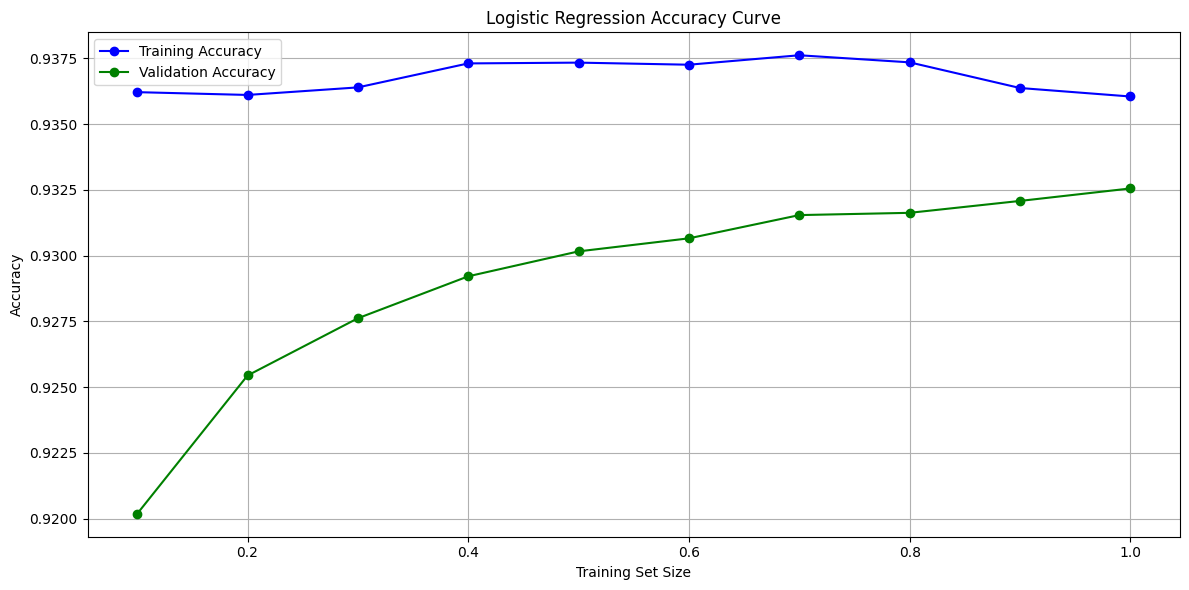

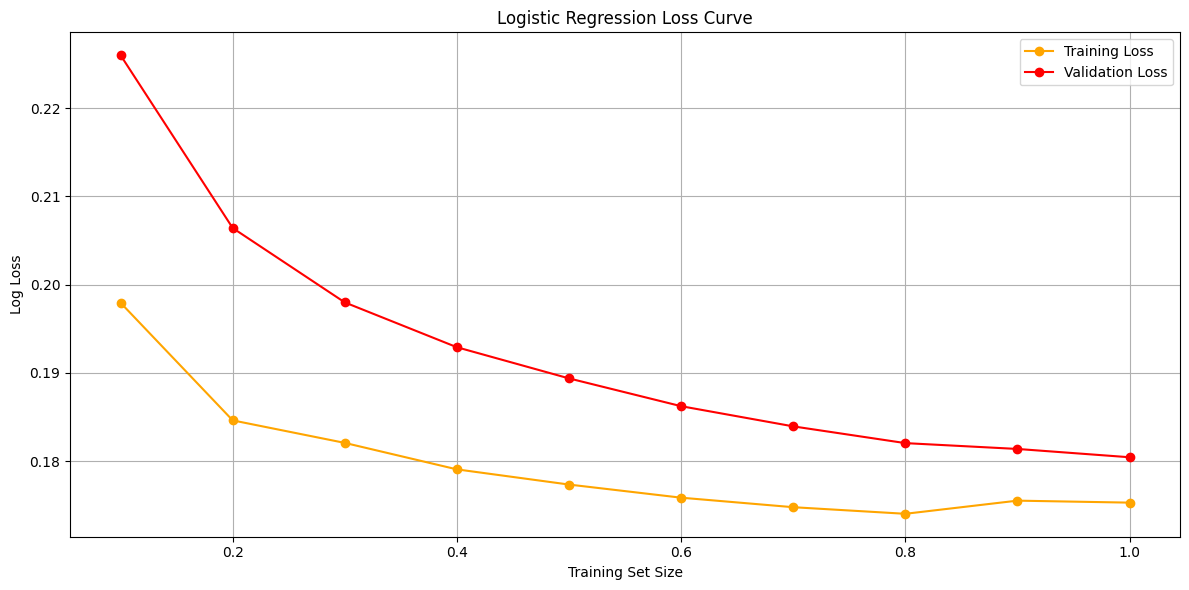

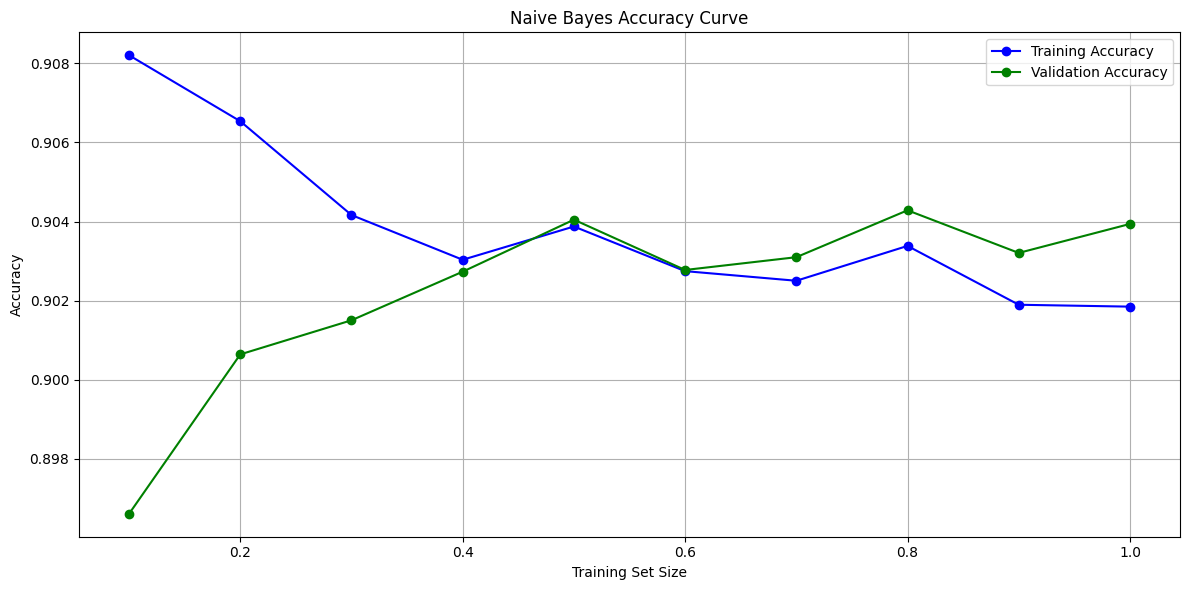

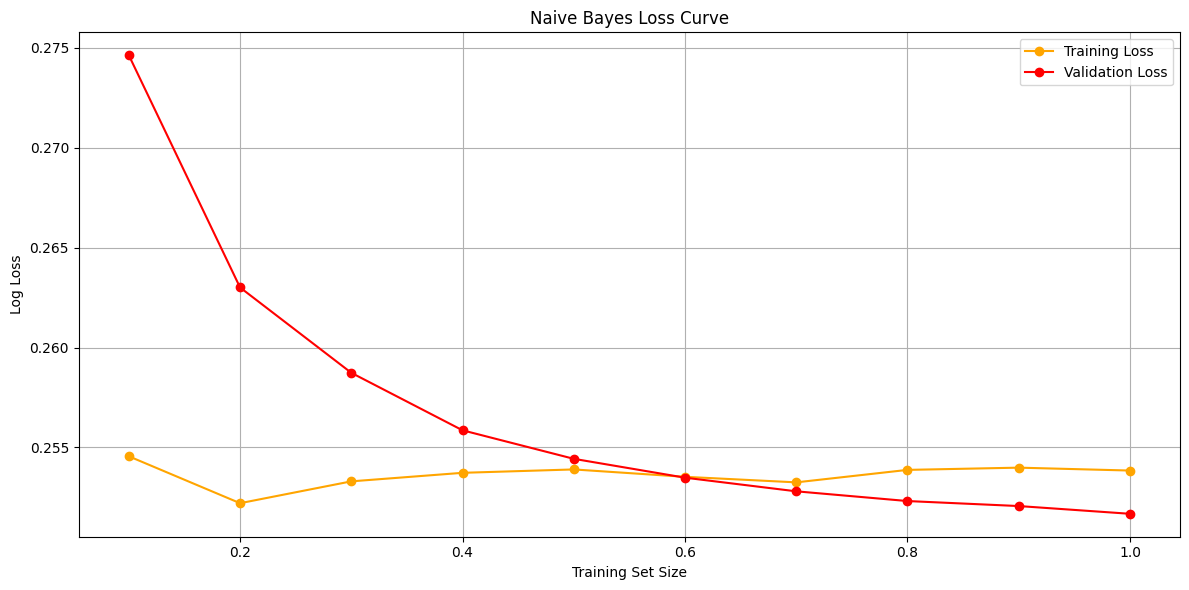

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import train_test_split

# Load your preprocessed dataset
data_path = r"/content/your_preprocessed_data.xlsx"  # Update with your actual file path
data = pd.read_excel(data_path)

# Define the column names for text and target labels
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Convert text data to numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(data[text_column])  # Feature matrix
y = data[target_column]  # Target labels

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

# Arrays to store accuracy and loss
train_sizes = np.linspace(0.1, 1.0, 10)  # Progressively larger portions of the training data
train_accuracies = {name: [] for name in models}
val_accuracies = {name: [] for name in models}
train_losses = {name: [] for name in models}
val_losses = {name: [] for name in models}

# Loop through the models and different training data sizes
for name, model in models.items():
    for size in train_sizes:
        # Use a portion of the training data
        subset_size = int(size * X_train.shape[0])
        X_train_subset = X_train[:subset_size]
        y_train_subset = y_train[:subset_size]

        # Train the model on the subset
        model.fit(X_train_subset, y_train_subset)

        # Predict on the training subset and validation set
        y_train_pred = model.predict(X_train_subset)
        y_val_pred = model.predict(X_test)

        # Predict probabilities for loss calculation
        y_train_proba = model.predict_proba(X_train_subset)
        y_val_proba = model.predict_proba(X_test)

        # Calculate accuracy
        train_accuracies[name].append(accuracy_score(y_train_subset, y_train_pred))
        val_accuracies[name].append(accuracy_score(y_test, y_val_pred))

        # Calculate log loss (Logarithmic Loss)
        train_losses[name].append(log_loss(y_train_subset, y_train_proba))
        val_losses[name].append(log_loss(y_test, y_val_proba))

# Plot Accuracy Curve for Logistic Regression
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_accuracies['Logistic Regression'], label='Training Accuracy', marker='o', color='blue')
plt.plot(train_sizes, val_accuracies['Logistic Regression'], label='Validation Accuracy', marker='o', color='green')
plt.title('Logistic Regression Accuracy Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Loss Curve for Logistic Regression
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_losses['Logistic Regression'], label='Training Loss', marker='o', color='orange')
plt.plot(train_sizes, val_losses['Logistic Regression'], label='Validation Loss', marker='o', color='red')
plt.title('Logistic Regression Loss Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Accuracy Curve for Naive Bayes
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_accuracies['Naive Bayes'], label='Training Accuracy', marker='o', color='blue')
plt.plot(train_sizes, val_accuracies['Naive Bayes'], label='Validation Accuracy', marker='o', color='green')
plt.title('Naive Bayes Accuracy Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Loss Curve for Naive Bayes
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_losses['Naive Bayes'], label='Training Loss', marker='o', color='orange')
plt.plot(train_sizes, val_losses['Naive Bayes'], label='Validation Loss', marker='o', color='red')
plt.title('Naive Bayes Loss Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
